# Swiggy Sales Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Database

In [3]:
df = pd.read_excel("swiggy_data.xlsx")
df.head(5)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.tail(5)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [5]:
print(f"No of rows: {df.shape[0]} And No of columns: {df.shape[1]}")

No of rows: 197430 And No of columns: 10


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  str           
 1   City             197430 non-null  str           
 2   Order Date       197430 non-null  datetime64[us]
 3   Restaurant Name  197430 non-null  str           
 4   Location         197430 non-null  str           
 5   Category         197430 non-null  str           
 6   Dish Name        197430 non-null  str           
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 15.1 MB


In [7]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996809,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


### Total Sales

In [8]:
total_sales = df["Price (INR)"].sum().round(2)
print(f"Total Sales (INR): {total_sales}")

Total Sales (INR): 53012505.77


### Total Rating Average

In [9]:
total_avg_rating = df["Rating"].mean().round(2)
print(f"Total Average: {total_avg_rating}")

Total Average: 4.34


### Avg Order value

In [10]:
avg_order_value = df["Price (INR)"].mean().round(2)
print(f"Total Order Average Value: {avg_order_value}")

Total Order Average Value: 268.51


### Total Rating Count

In [11]:
rating_count = df["Rating Count"].sum()
print(f"Total Rating Count: {rating_count}")

Total Rating Count: 5591574


### Total Order Count

In [12]:
order_count = df["Order Date"].count()
# order_count = len(df)   also we can use this 
print(f"Total Order Count: {order_count}")

Total Order Count: 197430


# Charts Design

### Monthly Sales Trends

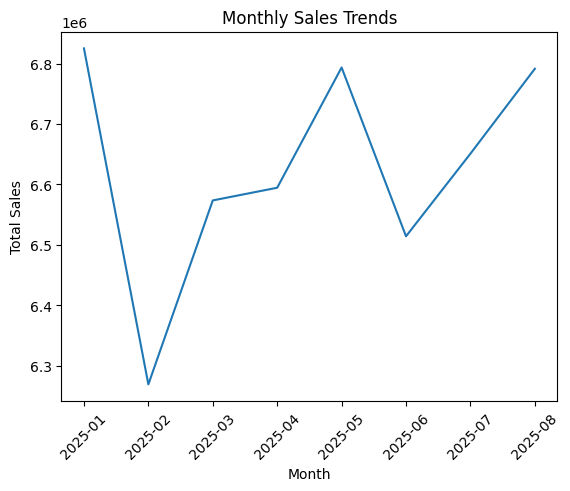

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()
plt.figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trends")
plt.show()

In [ ]:
# Define non-veg keywords
non_veg_keywords = ['chicken', 'mutton', 'fish', 'egg', 'prawn', 'kabab', 'tikka', 'meat', 'beef', 'pork']

# Create the new 'Category' column
df['Category'] = df['Dish Name'].apply(
    lambda x: 'Non-Veg' if any(word in str(x).lower() for word in non_veg_keywords) else 'Veg'
)

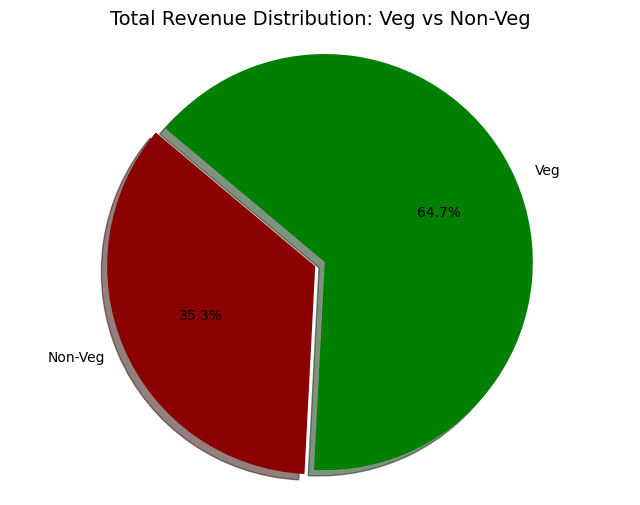

In [20]:

# 1. Group by Category and sum the Price
category_revenue = df.groupby('Category')['Price (INR)'].sum()

# 2. Extract labels and values
labels = category_revenue.index      # ['Non-Veg', 'Veg']
sizes = category_revenue.values      # The summed prices
colors = ['#8B0000', '#008000']     # Red for Non-Veg, Green for Veg

# 3. Create the Pie Chart using Matplotlib
plt.figure(figsize=(8, 6))
plt.pie(sizes, 
        labels=labels, 
        autopct='%1.1f%%',           # Display percentage with one decimal
        colors=colors, 
        startangle=140, 
        explode=(0.05, 0),           # Slightly separate the first slice
        shadow=True)

plt.title('Total Revenue Distribution: Veg vs Non-Veg', fontsize=14)
plt.axis('equal')                    # Ensures the pie is a circle
plt.show()


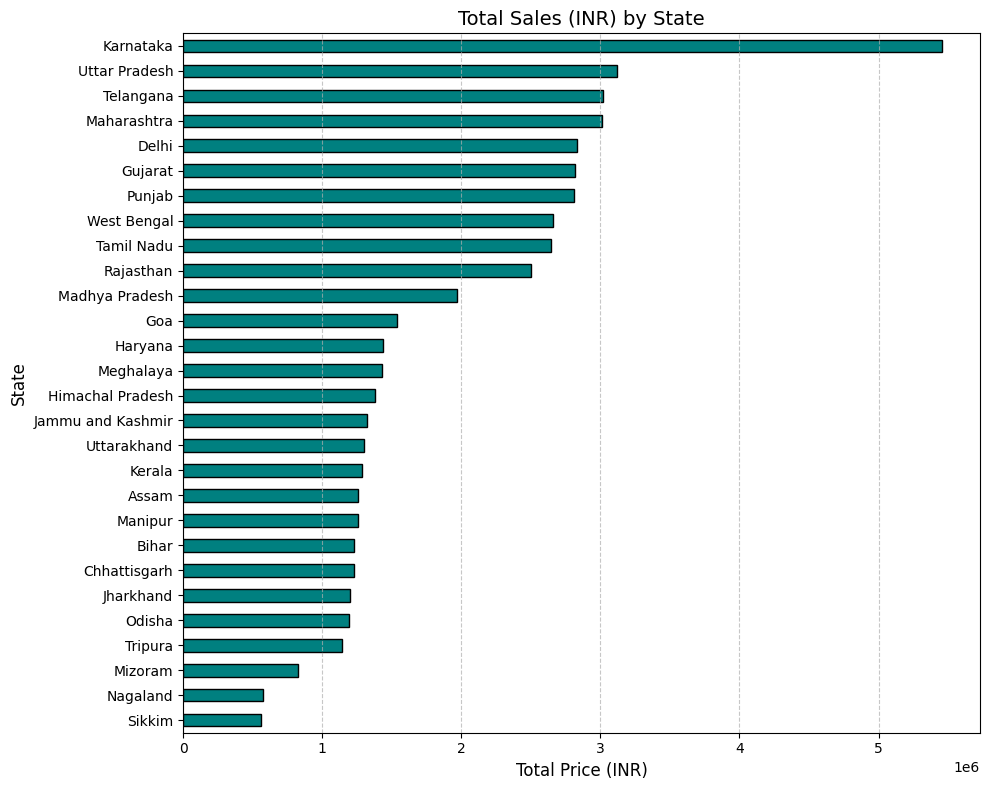

In [25]:


# 1. Group by State and sum the Price (INR)
# Assuming 'df' is your existing DataFrame
state_data = df.groupby('State')['Price (INR)'].sum().sort_values(ascending=True)

# 2. Create the horizontal bar chart
plt.figure(figsize=(10, 8))
state_data.plot(kind='barh', color='teal', edgecolor='black')

# 3. Add labels and title
plt.title('Total Sales (INR) by State', fontsize=14)
plt.xlabel('Total Price (INR)', fontsize=12)
plt.ylabel('State', fontsize=12)

# 4. Optional: Add a grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


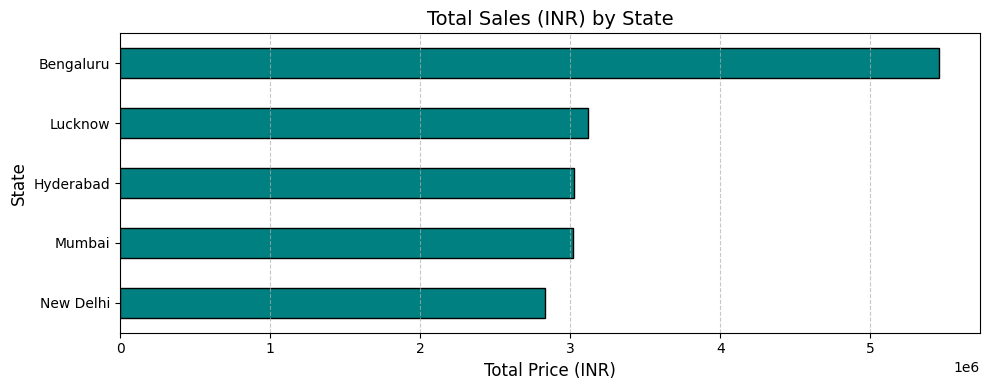

In [24]:


# 1. Group by State and sum the Price (INR)
# Assuming 'df' is your existing DataFrame
state_data = df.groupby('City')['Price (INR)'].sum().nlargest(5).sort_values(ascending=True)

# 2. Create the horizontal bar chart
plt.figure(figsize=(10, 4))
state_data.plot(kind='barh', color='teal', edgecolor='black')

# 3. Add labels and title
plt.title('Total Sales (INR) by State', fontsize=14)
plt.xlabel('Total Price (INR)', fontsize=12)
plt.ylabel('State', fontsize=12)

# 4. Optional: Add a grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
